In [1]:
# Import packages, pre-processing
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn import preprocessing
from sklearn.naive_bayes import GaussianNB

In [2]:
# Import dataset
filename='audiology.standardized.csv.data'
folder="V:/Other/Other/DS/data/"
data = pd.read_csv(folder+filename,header=None)

In [3]:
print(data)
type(data)

    0         1  2       3       4           5  6         7  8  9   ... 61 62  \
0    f      mild  f  normal  normal           ?  t         ?  f  f  ...  f  f   
1    f  moderate  f  normal  normal           ?  t         ?  f  f  ...  f  f   
2    t      mild  t       ?  absent        mild  t         ?  f  f  ...  f  f   
3    t      mild  t       ?  absent        mild  f         ?  f  f  ...  f  f   
4    t      mild  f  normal  normal        mild  t         ?  f  f  ...  f  f   
..  ..       ... ..     ...     ...         ... ..       ... .. ..  ... .. ..   
195  t      mild  f  absent  normal        mild  t         ?  f  f  ...  f  f   
196  t      mild  f  normal  absent        mild  f         ?  f  f  ...  f  f   
197  f    normal  f  normal  normal  unmeasured  f  degraded  f  f  ...  f  f   
198  t      mild  f  normal  normal  unmeasured  f         ?  f  f  ...  f  f   
199  t    normal  f  normal  normal  unmeasured  f         ?  f  f  ...  f  f   

            63 64  65 66 67

pandas.core.frame.DataFrame

In [4]:
# Setup data
# Audiological data
X=data.iloc[:,0:-2]
# Etiologies (classes)
y=data.iloc[:,-1]

In [5]:
# Represent categorical variables numerically
le = preprocessing.LabelEncoder()

# Transform etiology data
yt=le.fit_transform(y)

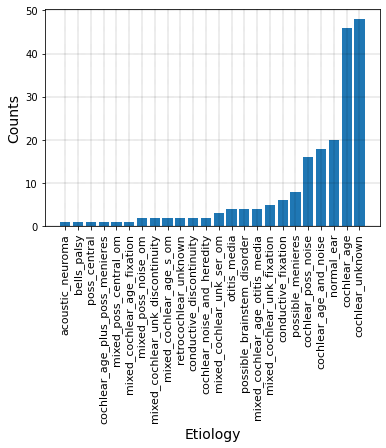

In [6]:
# Bar plot etiology counts
et_string=np.unique(y)
et_counts=np.arange(0,np.max(yt)+1)
for i in et_counts:
    et_counts[i]=(sum(yt==i))   

# Return indices of sorted array by size
et_sort=np.argsort(et_counts)    
# Plot
plt.grid(color = 'black', linestyle = '--', linewidth = 0.2)
plt.bar(np.arange(0,len(et_counts)),et_counts[et_sort])
plt.xlabel("Etiology", fontsize=14)   
plt.ylabel("Counts", fontsize=14) 
plt.xticks(range(len(et_string)),et_string[et_sort],rotation='vertical', fontsize=11)
plt.show()

In [7]:
# Transform entire audiological predictor data numerically using for loop
Xt=X
for i in np.arange(0,Xt.shape[1]):
    Xt[i] = le.fit_transform(Xt[i])
# Convert dataframe to array
Xt=np.array(Xt)
# Make X original data again (unsure why it gets transformed)    
X=data.iloc[:,0:-2]
print(Xt)

C:\Users\bc478\AppData\Local\Temp\ipykernel_17308\1936923069.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Xt[i] = le.fit_transform(Xt[i])


[[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 ...
 [0 2 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 2 0 ... 0 0 0]]


In [8]:
# Setup training and test data using data with known etiolgies
known_idx=np.array(np.where(yt!=7))
Xt_known=np.squeeze(Xt[known_idx,:])
y2=np.squeeze(yt[known_idx])

In [9]:
# Create and run model
# % test set
test_pc=20
ntest=np.round_(Xt_known.shape[0]*(test_pc/100))
# convert float to int
ntest=int(ntest)

# Randomly select indices to split rows into training/testing sets 
trainidx=np.arange(0,Xt_known.shape[0])
testidx=np.array(random.sample(range(Xt_known.shape[0]), ntest))
trainidx = np.delete(trainidx, testidx)

# Split predictor data into training/testing sets
X_train = Xt_known[trainidx,:]
X_test = Xt_known[testidx,:]

# Split target data into training/testing sets
y_train = y2[trainidx]
y_test = y2[testidx]

In [10]:
######################################################################################################
# Train a Gaussian Naive Bayes classifier
# Setup model
mdl = GaussianNB()

# Fit model
mdl.fit(X_train, y_train)
print(mdl)

# Predict y
y_pred = mdl.predict(X_test)

GaussianNB()


In [11]:
# Print metrics, evaluation
print('Training set score = {:.3f}'.format(mdl.score(X_train, y_train)))
print('Test set score = {:.3f}'.format(mdl.score(X_test, y_test)))
print(sum(y_test==y_pred),'out of ',len(y_test),'classifications correct')

# Print prediction strings
print(np.column_stack((et_string[y_test]+" predicted to be "+et_string[y_pred])))

Training set score = 0.975
Test set score = 0.633
19 out of  30 classifications correct
[['cochlear_age_and_noise predicted to be cochlear_age_and_noise'
  'cochlear_age_and_noise predicted to be cochlear_age_and_noise'
  'cochlear_age_and_noise predicted to be cochlear_age_and_noise'
  'cochlear_age predicted to be cochlear_age'
  'cochlear_age predicted to be cochlear_age'
  'cochlear_age predicted to be cochlear_age'
  'conductive_discontinuity predicted to be otitis_media'
  'cochlear_age_and_noise predicted to be cochlear_age'
  'cochlear_poss_noise predicted to be cochlear_poss_noise'
  'normal_ear predicted to be cochlear_poss_noise'
  'cochlear_age predicted to be cochlear_age'
  'cochlear_age predicted to be cochlear_age_and_noise'
  'cochlear_age_and_noise predicted to be cochlear_age_and_noise'
  'cochlear_age predicted to be possible_menieres'
  'cochlear_poss_noise predicted to be cochlear_poss_noise'
  'normal_ear predicted to be possible_menieres'
  'normal_ear predicted

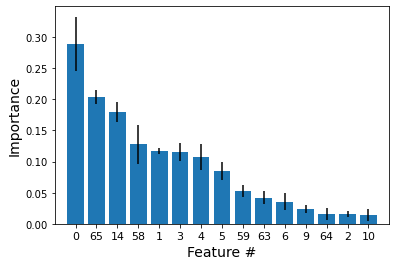

In [12]:
# Calculate feature importance using permutation importance technique
imps = permutation_importance(mdl, Xt_known, y2)
importance = imps.importances_mean
importance_idx = np.argsort(importance)[::-1]
features=np.arange(0,Xt.shape[1])

# # Print feature importance
# print("Feature importance")
# for i in range(Xt_known.shape[1]):
#     print("(%s) (%f)" % (features[importance_idx[i]], importance[importance_idx[i]]))

rankimportance=importance[importance_idx]
featureimportance=features[importance_idx]
featureimportance_std=imps.importances_std[importance_idx]  
# Plot nfplot most important features
nfplot=15
plt.bar(np.arange(0,nfplot),rankimportance[0:nfplot],yerr=featureimportance_std[0:nfplot])
plt.xticks(np.arange(0,nfplot),featureimportance[0:nfplot],fontsize=11)
plt.xlim([-1,nfplot])
plt.xlabel("Feature #", fontsize=14)   
plt.ylabel("Importance", fontsize=14) 
plt.show()

In [13]:
# Now use model on data with unknown etiologies
# Setup unknown etiology data
unknown_idx=np.array(np.where(yt==7))
X_unknown=X.iloc[np.squeeze(np.array(unknown_idx, dtype=np.int32))]
Xt_unknown=np.squeeze(Xt[unknown_idx,:])

# Predict etiologies of unknown etiology data
unknown_predict=mdl.predict(Xt_unknown)
et_string[unknown_predict]

# Put data and predictions of unknown into dataframe
predictionDf=pd.DataFrame(X_unknown)
#predictionDf['Predictions']=unknown_predict
predictionDf['StrPredictions']=et_string[unknown_predict]
print(predictionDf)

     0         1  2         3         4           5  6  7  8  9  ... 60 61 62  \
0    f      mild  f    normal    normal           ?  t  ?  f  f  ...  f  f  f   
1    f  moderate  f    normal    normal           ?  t  ?  f  f  ...  f  f  f   
6    f      mild  f    normal    normal        mild  t  ?  f  f  ...  f  f  f   
7    f      mild  f    normal    normal        mild  t  ?  f  f  ...  f  f  f   
8    f    severe  f         ?         ?           ?  t  ?  f  f  ...  f  f  f   
12   f    severe  f    normal    normal    moderate  t  ?  f  f  ...  f  f  f   
19   f    normal  f    normal  elevated           ?  f  ?  f  f  ...  f  f  f   
24   f  moderate  f  elevated  elevated           ?  t  ?  f  f  ...  f  f  f   
25   f    normal  f    normal    normal      normal  t  ?  f  f  ...  f  f  f   
26   f    normal  f    normal  elevated      normal  t  ?  f  f  ...  f  f  f   
29   f      mild  f  elevated    normal        mild  t  ?  f  f  ...  f  f  f   
32   f    normal  f    norma